# Python for data analysis and visualisation

## Online short course at the University of St Andrews

## Final assignment

### Sam Gorick

In [3]:
import sys
sys.path.append("..")

In [ ]:
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as pyp
from src.ErrorHandling import check_column_type_consistency, check_record_dupes, regex_column_rename

We start with exploring the content of the dataset.

In [6]:
df = pd.read_csv("../data/Scotland_teaching_file_1PCT.csv")
df

,Record_Number,Region,RESIDENCE_TYPE,Family_Composition,sex,age,Marital_Status,student,Country_Of_Birth,health,Ethnic_Group,religion,Economic_Activity,Occupation,industry,Hours_Worked_Per_Week,Approximate_Social_Grade
0,1,S92000003,P,1,1,4,2,2,2,2,1,5,1,5,5,4,3
1,2,S92000003,P,0,1,3,1,2,1,2,1,1,1,1,8,3,2
2,3,S92000003,P,1,2,4,2,2,1,3,1,1,1,4,8,2,4
3,4,S92000003,P,1,2,6,2,2,1,1,1,1,1,2,8,4,2
4,5,S92000003,P,4,2,4,4,2,1,2,1,1,1,3,11,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63383,63384,S92000003,P,1,1,2,1,1,1,1,1,2,6,X,X,X,3
63384,63385,S92000003,P,1,1,4,2,2,1,1,1,1,1,3,9,3,2
63385,63386,S92000003,P,1,1,5,2,2,1,1,1,9,1,8,3,4,4
63386,63387,S92000003,P,4,2,1,1,1,1,1,1,9,X,X,X,X,X


# Check Duplicates
## The Record_Number field should be unique.

We can use the check_record_dupes function to evaluate the uniqueness of this field. If duplicates are found, the first instance of the record is kept in the dataset. Subsequent records are deleted and outputted to a separate file.

In [7]:
check_record_dupes(df,"Record_Number","Exceptions/DuplicatedRecords.txt",True)

'Field Contains Unique Values'

# Check Field Values Are Valid
## Read List of Acceptable Values From definitions.py

Want to ensure that:
-     All Entries Are Valid
-     All Columns Are Checked Properly


In [8]:
# First, extract the valid field values from definitions.py
from src.definitions.definitions import *

# Now for each column, extract the list of acceptable values
variable_definitions = VARIABLE_DEFINITIONS.items()
check_column_type_consistency(df,variable_definitions,sample_size=None)

# Get the list of invalid columns as a variable
invalid_columns = check_column_type_consistency(df,variable_definitions,sample_size=None)

Column Sex Not Found
Column Age Not Found
Column Student Not Found
Column Health Not Found
Family_Composition: All values valid
Marital_Status: All values valid
Country_Of_Birth: All values valid
Ethnic_Group: All values valid
Column Religion Not Found
Column Economic Activity Not Found
Occupation: All values valid
Column Industry Not Found
Hours_Worked_Per_Week: All values valid
Approximate_Social_Grade: All values valid
Column Sex Not Found
Column Age Not Found
Column Student Not Found
Column Health Not Found
Family_Composition: All values valid
Marital_Status: All values valid
Country_Of_Birth: All values valid
Ethnic_Group: All values valid
Column Religion Not Found
Column Economic Activity Not Found
Occupation: All values valid
Column Industry Not Found
Hours_Worked_Per_Week: All values valid
Approximate_Social_Grade: All values valid


- For each invalid column, identify and suggest an appropriate column name to use.

- Prompt the user to agree or disagree with the suggested column name.

- If the user agrees, overwrite the column name in the DataFrame.

- Re-run `check_column_type_consistency` to ensure there are no remaining unmatched columns.

In [9]:
regex_column_rename(invalid_columns, df)

invalid_columns = check_column_type_consistency(df,variable_definitions,sample_size=None)

if len(invalid_columns) > 0:
    print("Unmatched Columns Still Remain. Amend either the definitions.py file or dataframe")
    invalid_columns
else:
    print("Rename Successful, no columns left unmatched")

Potential match found:
Expected: Sex
DataFrame: sex
Renamed 'sex' to 'Sex'
Potential match found:
Expected: Age
DataFrame: age
Renamed 'age' to 'Age'
Potential match found:
Expected: Student
DataFrame: student
Renamed 'student' to 'Student'
Potential match found:
Expected: Health
DataFrame: health
Renamed 'health' to 'Health'
Potential match found:
Expected: Religion
DataFrame: religion
Renamed 'religion' to 'Religion'
Potential match found:
Expected: Economic Activity
DataFrame: Economic_Activity
Renamed 'Economic_Activity' to 'Economic Activity'
Potential match found:
Expected: Industry
DataFrame: industry
Renamed 'industry' to 'Industry'
Sex: All values valid
Age: All values valid
Student: All values valid
Health: All values valid
Family_Composition: All values valid
Marital_Status: All values valid
Country_Of_Birth: All values valid
Ethnic_Group: All values valid
Religion: All values valid
Economic Activity: All values valid
Occupation: All values valid
Industry: All values valid
H

# Analyze The Data

- Number Of Records In The Dataset
- Variable Type in Dataset
- Unique Values & Value Distribution

In [10]:
#Total Records
total_records = len(df)
total_records

#Data Type of each column
data_types = df.dtypes

# Extract actual values from the Variable Definitions Dictionary
column_keys = VARIABLE_DEFINITIONS.keys()
df_mapped = df.copy()
for column, mapping in VARIABLE_DEFINITIONS.items():
    if column in df.columns:
        df_mapped[column] = df[column].astype("string").map(mapping)


# Initialise list of columns to check, ie everything except Record Number & Region
columns_to_check = [
    column for column in df_mapped.columns
    if column not in ["Record_Number", "Region"]
]

# Calculate the number of occurrences of each distinct value
for column in columns_to_check:
    print("---------")
    print(df_mapped[column].value_counts(dropna=False))

---------
RESIDENCE_TYPE
P    62239
C     1149
Name: count, dtype: int64
---------
Family_Composition
Married/same-sex civil partnership couple family            33337
Not in a family                                             11716
Lone parent family (female lead)                             7757
Cohabiting couple family                                     7660
No code required (residents of a communal establishment)     1149
Lone parent family (male head)                               1019
Other related family                                          750
Name: count, dtype: int64
---------
Sex
Female    32696
Male      30692
Name: count, dtype: int64
---------
Age
0 to 15        10980
45 to 54        9336
35 to 44        8963
25 to 34        8056
55 to 64        7854
16 to 24        7541
65 to 74        5731
75 and over     4927
Name: count, dtype: int64
---------
Marital_Status
Single (Never married or never registered a same-sex civil partnership)                  29611
Married or

# Plot Data Distribution

- Create Bar Chart for Distribution of Records of Each Age Group
- First Create a dataframe with the distinct values and frequency of Age Group Occurrences

Text(0, 0.5, 'Count')

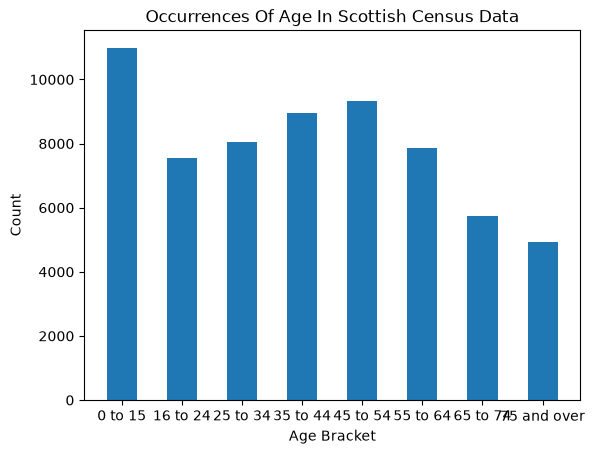

In [21]:
# Create Bar Chart for Distribution of Records of Each Age Group

age_brackets = df_mapped["Age"].value_counts(dropna=False).reset_index()
age_brackets.columns = ["Age Bracket", "Count"]

# Sort column values by age bracket instead of Count
age_brackets = age_brackets.sort_values("Age Bracket")

pyp.bar(x = age_brackets["Age Bracket"], height = age_brackets["Count"], width=0.5)
pyp.title("Occurrences Of Age In Scottish Census Data")
pyp.xlabel("Age Bracket")
pyp.ylabel("Count")

(array([    0.,  2000.,  4000.,  6000.,  8000., 10000., 12000., 14000.,
        16000.]),
 [Text(0.0, 0, '0'),
  Text(2000.0, 0, '2000'),
  Text(4000.0, 0, '4000'),
  Text(6000.0, 0, '6000'),
  Text(8000.0, 0, '8000'),
  Text(10000.0, 0, '10000'),
  Text(12000.0, 0, '12000'),
  Text(14000.0, 0, '14000'),
  Text(16000.0, 0, '16000')])

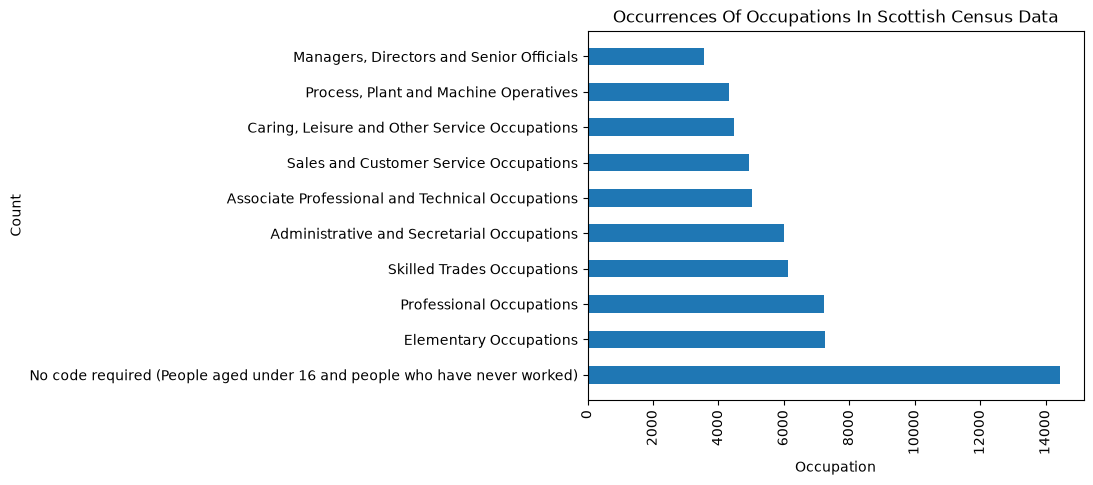

In [ ]:
# Create Bar Chart for Distribution of Records of Each Age Group

occupations = df_mapped["Occupation"].value_counts(dropna=False).reset_index()
occupations.columns = ["Occupation", "Count"]

# Orient Bar Graph Horizontally, easier to read given the more verbose category definitions
pyp.barh(y = occupations["Occupation"], width = occupations["Count"], height=0.5)
pyp.title("Occurrences Of Occupations In Scottish Census Data")
pyp.xlabel("Occupation")
pyp.ylabel("Count")

pyp.xticks(rotation=90)

# Additional Requirements
## Easy

- Pie Chart For percentage of records for each health descriptor
- Pie Chart for percentage of records for each ethnic group

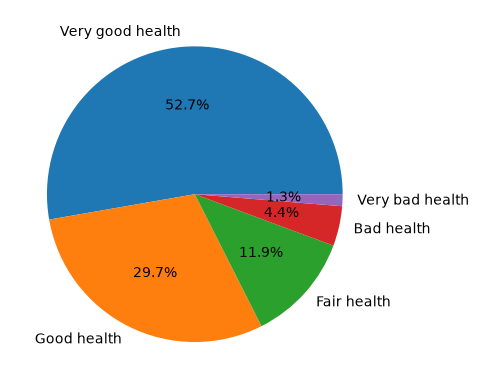

In [ ]:
# Health Distribution
health = df_mapped["Health"].value_counts(dropna=False).reset_index()
health.columns = ["Health Status", "Count"]

labels = health["Health Status"]
sizes = health["Count"]

# Create Pie Chart and Add percentages
fig, ax = pyp.subplots()
ax.pie(sizes,labels=labels,autopct="%1.1f%%")

Text(0.5, 1.0, 'Distribution Of Ethnic Groups In Scottish Census Data')

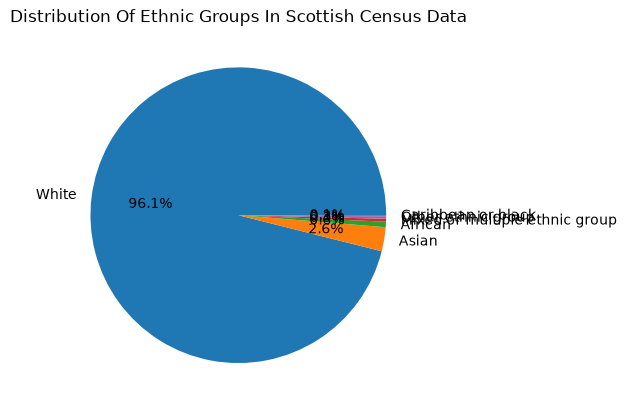

In [37]:
# Ethnic Group Distribution
ethnic_group = df_mapped["Ethnic_Group"].value_counts(dropna=False).reset_index()
ethnic_group.columns = ["Ethnic Group", "Count"]

labels = ethnic_group["Ethnic Group"]
sizes = ethnic_group["Count"]

# Create Pie Chart and Add percentages
fig, ax = pyp.subplots()
ax.pie(sizes, labels=labels, autopct="%1.1f%%")
ax.set_title("Distribution Of Ethnic Groups In Scottish Census Data")



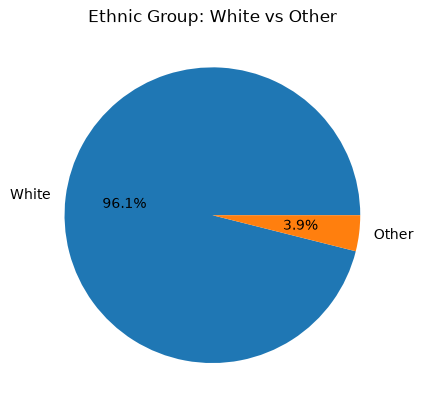

In [ ]:
# For Scottish census data, this bar chart makes it difficult to see the disrtibution of non-white citizens as 96.1% of the population is white.
# Split into two pie charts. The first comparing the white population to non-white population, the second, showing a distribution of the non-white population

# Count ethnic groups
ethnic_group = (
    df_mapped["Ethnic_Group"]
    .value_counts(dropna=False)
    .reset_index()
)

ethnic_group.columns = ["Ethnic Group", "Count"]

# Separate White from Other
white_count = ethnic_group.loc[
    ethnic_group["Ethnic Group"] == "White", "Count"
].iloc[0]

other_count = ethnic_group.loc[
    ethnic_group["Ethnic Group"] != "White", "Count"
].sum()

labels = ["White", "Other"]
sizes = [white_count, other_count]

fig, ax = pyp.subplots()

ax.pie(sizes,labels=labels,autopct="%1.1f%%")

ax.set_title("Ethnic Group: White vs Other")

pyp.show()

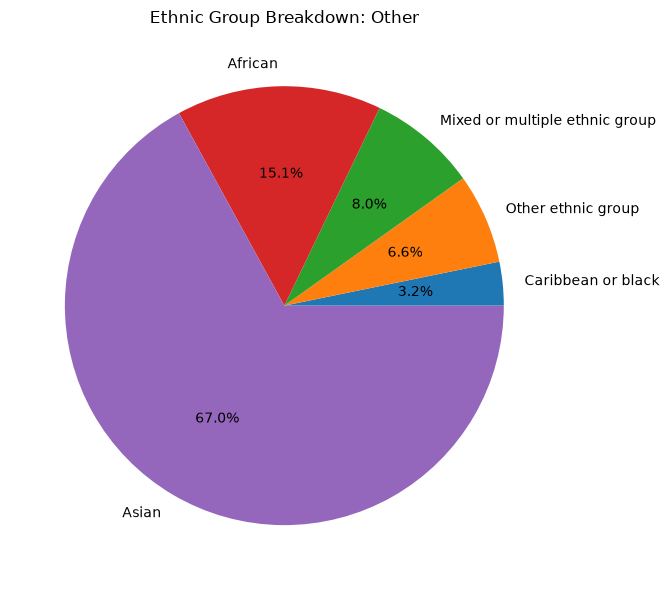

In [41]:
other_groups = ethnic_group[
    ethnic_group["Ethnic Group"] != "White"
].copy()

other_groups = other_groups.sort_values("Count", ascending=True)

labels = other_groups["Ethnic Group"]
sizes = other_groups["Count"]

fig, ax = pyp.subplots(figsize=(10, 6))

ax.pie(sizes, labels=labels,autopct="%1.1f%%")

ax.set_title("Ethnic Group Breakdown: Other")
pyp.tight_layout()
pyp.show()